In [1]:
import numpy as np
import sys
import argparse
sys.path.append('/global/homes/l/lonappan/workspace/cobi')
from cobi import mpi
from cobi.simulation import LATsky
from cobi.spectra import Spectra
from cobi.mle import MLE
from tqdm import tqdm

In [2]:
libdir = '/global/cfs/cdirs/sobs/cosmic_birefringence/COBIv1'
nside = 2048
cb_model = "iso"
beta = 0.3

In [3]:
alpha = [-0.1,-0.1,0.2,0.2,.15,.15]
alpha_err = 0.05
bp = True
nm = 'NC'

In [4]:
lat = LATsky(libdir, nside, cb_model, beta, alpha=alpha, alpha_err=alpha_err, bandpass=bp,noise_model=nm,noise_sensitivity='goal',nsplits=2)
spec = Spectra(lat, libdir, cache=True, parallel=0,lmax=3000)

CMB : INFO - Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected
Noise : INFO - Noise Model: sensitivity mode 'goal'.
Noise : INFO - Noise Model:[LAT] White + 1/f noise v3.1.1
Spectra : INFO - Setting lmax to 3000
Spectra : INFO - Reading apodised mask from /global/cfs/cdirs/sobs/cosmic_birefringence/COBIv1/spectra_N2048_lmax3000_aposcale2p0/workspaces/mask_N2048_aposcale2p0_CO_PS.fits
Spectra : INFO - Reading coupling Matrix from /global/cfs/cdirs/sobs/cosmic_birefringence/COBIv1/spectra_N2048_lmax3000_aposcale2p0/workspaces/coupling_matrix_N2048_fsky0p55_aposcale2p0_bw1_CO_PS.fits
Spectra : INFO - No parallelization


In [10]:
fit = "Ad + beta + alpha"
rm_same_tube = True
binwidth = 10
bmin = 100
bmax = 3000
mle = MLE(libdir,spec,fit, alpha_per_split=False,rm_same_tube=rm_same_tube,binwidth=binwidth,bmin=bmin,bmax=bmax)

CMB : INFO - Loading CMB power spectra from file
CMB : INFO - Isotropic(constant) cosmic birefringence model selected


In [11]:
targets = ['beta', '27', '39', '93', '145', '225', '280']
samples = {k: [] for k in targets}

for i in tqdm(range(100)):
    est = mle.estimate_angles(i)
    for k in targets:
        if k in est:
            samples[k].append(est[k])

stats = {
    k: {'mean': float(np.mean(v)), 'std': float(np.std(v))}
    for k, v in samples.items()
    if len(v) > 0
}

stats

100%|██████████| 100/100 [00:00<00:00, 4705.09it/s]


{'beta': {'mean': 0.258483709467297, 'std': 0.04940100027034967},
 '27': {'mean': -0.04986110093225456, 'std': 0.08335575254949311},
 '39': {'mean': -0.05522579439963355, 'std': 0.07162522268849564},
 '93': {'mean': 0.2420948926677485, 'std': 0.07899206292895952},
 '145': {'mean': 0.24444712586000678, 'std': 0.07133926269719292},
 '225': {'mean': 0.193583648127656, 'std': 0.06431667580994253},
 '280': {'mean': 0.18099195523643008, 'std': 0.06617794121188238}}

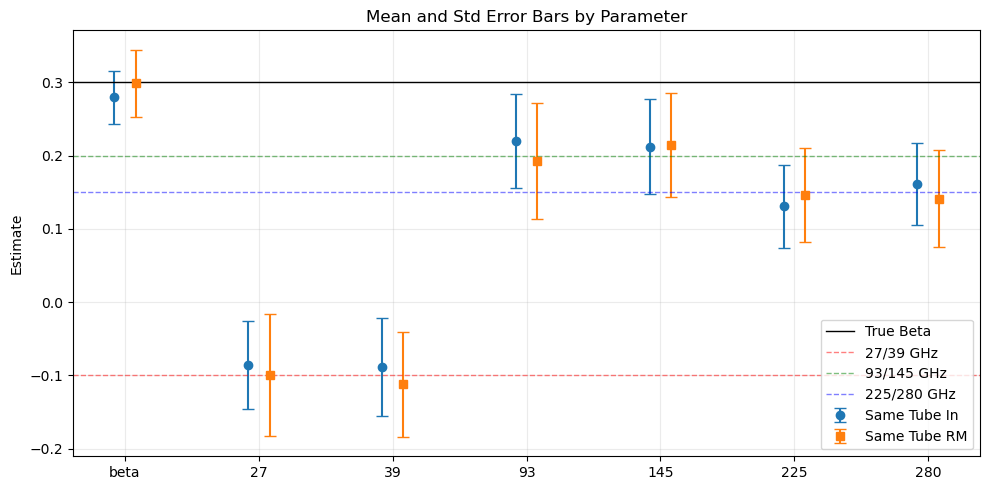

In [25]:
import matplotlib.pyplot as plt
import numpy as np

same_tube_in = {
    'beta': {'mean': 0.27978703461866253, 'std': 0.036221529276000405},
    '27': {'mean': -0.085851352576666116, 'std': 0.06051273748802741},
    '39': {'mean': -0.088848603830950034, 'std': 0.06710013977716554},
    '93': {'mean': 0.2197922401084771, 'std': 0.0638041194243167},
    '145': {'mean': 0.21203998200939753, 'std': 0.06487845351505024},
    '225': {'mean': 0.13088203556596237, 'std': 0.05654471697617018},
    '280': {'mean': 0.16088443902617874, 'std': 0.05566031493275922},
}

same_tube_rm = {
    'beta': {'mean': 0.298483709467297, 'std': 0.0460100027034967},
    '27': {'mean': -0.09986110093225456, 'std': 0.08335575254949311},
    '39': {'mean': -0.1122579439963355, 'std': 0.07162522268849564},
    '93': {'mean': 0.1920948926677485, 'std': 0.07899206292895952},
    '145': {'mean': 0.21444712586000678, 'std': 0.07133926269719292},
    '225': {'mean': 0.14583648127656, 'std': 0.06431667580994253},
    '280': {'mean': 0.14099195523643008, 'std': 0.06617794121188238},
}

params = ['beta', '27', '39', '93', '145', '225', '280']
x = np.arange(len(params))

mean_1 = [same_tube_in[p]['mean'] for p in params]
std_1 = [same_tube_in[p]['std'] for p in params]
mean_2 = [same_tube_rm[p]['mean'] for p in params]
std_2 = [same_tube_rm[p]['std'] for p in params]

plt.figure(figsize=(10, 5))
plt.errorbar(x - 0.08, mean_1, yerr=std_1, fmt='o', capsize=4, label='Same Tube In')
plt.errorbar(x + 0.08, mean_2, yerr=std_2, fmt='s', capsize=4, label='Same Tube RM')
plt.axhline(0.3, color='k', linewidth=1, alpha=1, label='True Beta')
plt.axhline(-0.1, color='r', linewidth=1,ls='--', alpha=0.5, label='27/39 GHz')
plt.axhline(0.2, color='g', linewidth=1,ls='--', alpha=0.5, label='93/145 GHz')
plt.axhline(0.15, color='b', linewidth=1,ls='--', alpha=0.5, label='225/280 GHz')
plt.xticks(x, params)
plt.ylabel('Estimate')
plt.title('Mean and Std Error Bars by Parameter')
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()